In [1]:
%load_ext autoreload
%autoreload 2


# Trading Competition Training

Train Nash-DQN and locally linear-quadratic SRE-DQN on the shared trading competition environment.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / 'AGENTS.md').exists() and (path / 'continuous_action_space').exists():
            return path
    raise RuntimeError('Could not locate repo root')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXPERIMENT_DIR = REPO_ROOT / 'continuous_action_space' / 'trading_competition'
MODEL_ROOT = EXPERIMENT_DIR / 'pt_files'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4)
print('Repo root:', REPO_ROOT)
print('Model root:', MODEL_ROOT)
print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Repo root: /home/wowthecoder/SRE-DQN
Model root: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files
Using device: cuda


## Imports And Helpers


In [3]:
from continuous_action_space.trading_competition.experiment_config import (
    NUM_PLAYERS as num_players,
    sim_dict,
    norm_mean,
    norm_std,
    T,
    make_sim_obj,
    seed_everything,
    configure_torch_gpu_math,
    eps_slug,
    seed_slug,
    BASE_SEED,
    MAX_STEPS,
    LLQ_SRE_EPS_LIST,
    SRE_EPS_REG,
    SRE_DELTA_MIN,
    SRE_GAMMA,
    NET_KWARGS,
)
from continuous_action_space.trading_competition.training import run_training_loop
from continuous_action_space.locally_linear_quadratic.NashAgent_lib import NashNN
from continuous_action_space.locally_linear_quadratic.sre_agent import SreNN

configure_torch_gpu_math()
sim_obj = make_sim_obj()


def make_nash_action(agent, eps_b, noise_std):
    del eps_b
    def fn(cur_s, cur_ivt):
        mu = agent.predict_action(cur_s, cur_ivt)[:, 4]
        return mu + torch.randn_like(mu) * noise_std
    return fn


def make_llq_sre_action(agent, eps_b, noise_std):
    def fn(cur_s, cur_ivt):
        mu_sr = agent.compute_sre_action(cur_s, cur_ivt, eps_b)
        return mu_sr + torch.randn_like(mu_sr) * noise_std
    return fn


def make_eps_schedule(eps_0):
    def eps_schedule(k, num_sim):
        if SRE_EPS_DECAY is None:
            return eps_0
        return eps_0 * max(0.0, 1.0 - k / max(SRE_EPS_DECAY, 1))
    return eps_schedule


print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item(), '| impact=', sim_obj.impact)

Agents: 5 | T= 5 | dt= 0.5 | impact= sqrt


## Training Configuration


In [4]:
NASH_SEED = BASE_SEED
LLQ_SRE_TRAIN_SEED = BASE_SEED

NUM_SIM = 10000
RV_MIN = 0.5
RV_MAX = 2.5
EARLY_STOP = True
EARLY_LIM = 3000
MINI_BATCH = 128
SRE_EPS_DECAY = None

TRAINING_LOG_KWARGS = dict(
    loss_log_every=1000,
    eval_reward_every=1000,
    eval_episodes=500,
    log_best_updates=False,
    log_weight_saves=False,
)

NASH_RUN_TAG = seed_slug(NASH_SEED)
LLQ_SRE_RUN_TAG = seed_slug(LLQ_SRE_TRAIN_SEED)

NASH_MODEL_DIR = MODEL_ROOT / f'nash_{NASH_RUN_TAG}'
LLQ_SRE_MODEL_DIRS = {
    eps: MODEL_ROOT / f'llq_sre_eps_{eps_slug(eps)}_{LLQ_SRE_RUN_TAG}'
    for eps in LLQ_SRE_EPS_LIST
}

seed_everything(BASE_SEED)
print('NUM_SIM:', NUM_SIM, '| MAX_STEPS:', MAX_STEPS, '| MINI_BATCH:', MINI_BATCH)
print('LLQ Epsilon sweep:', LLQ_SRE_EPS_LIST, '| decay horizon:', SRE_EPS_DECAY)
print('Nash dir:', NASH_MODEL_DIR)

NUM_SIM: 10000 | MAX_STEPS: 10 | MINI_BATCH: 128
LLQ Epsilon sweep: [0.0, 0.01, 0.1, 0.5, 1.0] | decay horizon: None
Nash dir: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/nash_seed_20260409


## Train Nash-DQN


In [5]:
nash_agent = None
nash_loss = None
nash_train_time = None

NASH_MODEL_DIR.mkdir(parents=True, exist_ok=True)
seed_everything(NASH_SEED)
nash_agent = NashNN(**NET_KWARGS)
start = time.time()
nash_agent, nash_loss = run_training_loop(
    sim_obj=sim_obj,
    sim_dict=sim_dict,
    max_steps=MAX_STEPS,
    agent=nash_agent,
    make_action_fn=make_nash_action,
    eps_schedule_fn=None,
    num_sim=NUM_SIM,
    norm_mean=norm_mean,
    norm_std=norm_std,
    rv_min=RV_MIN,
    rv_max=RV_MAX,
    early_stop=EARLY_STOP,
    early_lim=EARLY_LIM,
    mini_batch=MINI_BATCH,
    path=str(NASH_MODEL_DIR),
    AN_file_name=str(NASH_MODEL_DIR / 'Action_Net'),
    VN_file_name=str(NASH_MODEL_DIR / 'Value_Net'),
    checkpoint_metadata={'trainer': 'nash_dqn', 'seed': int(NASH_SEED)},
    desc='Nash-DQN',
    **TRAINING_LOG_KWARGS,
)
nash_train_time = time.time() - start
print(f'Nash-DQN training time: {nash_train_time:.1f}s')


CUDA IS AVAILABLE!


Nash-DQN:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/wowthecoder/SRE-DQN/continuous_action_space/locally_linear_quadratic/NashAgent_lib.py:149: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ids = torch.tensor(torch.arange(self.num_players)).tile(num_entries).cuda()


Nash-DQN Episode 1000 | Total Loss 3651.0918 | V_loss 1831.0972 | A_loss 1819.9946
Nash-DQN Best so far | Episode 897 | Loss 2708.7666
Nash-DQN Eval rewards | Episode 1000 | Mean -1.3146 | Std 2.7089 | Agent means [-1.534, -1.207, -1.359, -1.261, -1.211]
Nash-DQN Episode 2000 | Total Loss 1260.4630 | V_loss 629.2488 | A_loss 631.2142
Nash-DQN Best so far | Episode 1671 | Loss 938.3861
Nash-DQN Eval rewards | Episode 2000 | Mean -1.3067 | Std 2.5869 | Agent means [-1.206, -1.247, -1.332, -1.433, -1.315]
Nash-DQN Episode 3000 | Total Loss 1155.4473 | V_loss 578.5752 | A_loss 576.8721
Nash-DQN Best so far | Episode 2034 | Loss 916.4919
Nash-DQN Eval rewards | Episode 3000 | Mean -1.3322 | Std 2.7369 | Agent means [-1.284, -1.42 , -1.123, -1.52 , -1.314]
Nash-DQN Episode 4000 | Total Loss 1227.2695 | V_loss 614.0689 | A_loss 613.2007
Nash-DQN Best so far | Episode 2034 | Loss 916.4919
Nash-DQN Eval rewards | Episode 4000 | Mean -1.2053 | Std 2.5620 | Agent means [-1.23 , -1.17 , -1.136, -1

## Train Locally Linear-Quadratic SRE-DQN


In [6]:
llq_sre_agents = {}
llq_sre_losses = {}
llq_sre_train_times = {}

for eps in LLQ_SRE_EPS_LIST:
    eps_dir = LLQ_SRE_MODEL_DIRS[eps]
    eps_dir.mkdir(parents=True, exist_ok=True)

    seed_everything(LLQ_SRE_TRAIN_SEED)
    sre_agent = SreNN(
        **NET_KWARGS,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
    )

    start = time.time()
    trained_agent, train_loss = run_training_loop(
        sim_obj=sim_obj,
        sim_dict=sim_dict,
        max_steps=MAX_STEPS,
        agent=sre_agent,
        make_action_fn=make_llq_sre_action,
        eps_schedule_fn=make_eps_schedule(eps),
        num_sim=NUM_SIM,
        norm_mean=norm_mean,
        norm_std=norm_std,
        rv_min=RV_MIN,
        rv_max=RV_MAX,
        early_stop=EARLY_STOP,
        early_lim=EARLY_LIM,
        mini_batch=MINI_BATCH,
        path=str(eps_dir),
        AN_file_name=str(eps_dir / f'LLQ_SRE_Action_Net_eps_{eps_slug(eps)}'),
        VN_file_name=str(eps_dir / f'LLQ_SRE_Value_Net_eps_{eps_slug(eps)}'),
        checkpoint_metadata={
            'trainer': 'llq_sre_dqn',
            'seed': int(LLQ_SRE_TRAIN_SEED),
            'eps_0': float(eps),
            'eps_decay_horizon': None if SRE_EPS_DECAY is None else int(SRE_EPS_DECAY),
            'eps_reg': float(SRE_EPS_REG),
            'delta_min': float(SRE_DELTA_MIN),
            'gamma': float(SRE_GAMMA),
        },
        desc=f'LLQ SRE-DQN eps={eps:g}',
        **TRAINING_LOG_KWARGS,
    )
    llq_sre_agents[eps] = trained_agent
    llq_sre_losses[eps] = train_loss
    llq_sre_train_times[eps] = time.time() - start
    print(f'LLQ SRE-DQN training time (eps={eps:g}): {llq_sre_train_times[eps]:.1f}s')


CUDA IS AVAILABLE!


LLQ SRE-DQN eps=0:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0 Episode 1000 | Total Loss 3654.7595 | V_loss 1832.2721 | A_loss 1822.4874
LLQ SRE-DQN eps=0 Best so far | Episode 897 | Loss 2710.4819
LLQ SRE-DQN eps=0 Eval rewards | Episode 1000 | Mean -1.3151 | Std 2.7090 | Agent means [-1.535, -1.207, -1.36 , -1.262, -1.211]
LLQ SRE-DQN eps=0 Episode 2000 | Total Loss 1294.2368 | V_loss 646.7424 | A_loss 647.4943
LLQ SRE-DQN eps=0 Best so far | Episode 1671 | Loss 948.7064
LLQ SRE-DQN eps=0 Eval rewards | Episode 2000 | Mean -1.3072 | Std 2.5884 | Agent means [-1.207, -1.247, -1.333, -1.434, -1.315]
LLQ SRE-DQN eps=0 Episode 3000 | Total Loss 1154.1754 | V_loss 578.0145 | A_loss 576.1609
LLQ SRE-DQN eps=0 Best so far | Episode 2034 | Loss 928.3716
LLQ SRE-DQN eps=0 Eval rewards | Episode 3000 | Mean -1.3324 | Std 2.7367 | Agent means [-1.284, -1.42 , -1.123, -1.52 , -1.314]
LLQ SRE-DQN eps=0 Episode 4000 | Total Loss 1222.8494 | V_loss 611.7635 | A_loss 611.0859
LLQ SRE-DQN eps=0 Best so far | Episode 2034 | Loss 928.3716
LLQ SRE

LLQ SRE-DQN eps=0.01:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0.01 Episode 1000 | Total Loss 3672.4512 | V_loss 1840.2407 | A_loss 1832.2103
LLQ SRE-DQN eps=0.01 Best so far | Episode 897 | Loss 2701.0305
LLQ SRE-DQN eps=0.01 Eval rewards | Episode 1000 | Mean -1.3145 | Std 2.7093 | Agent means [-1.534, -1.206, -1.359, -1.261, -1.211]
LLQ SRE-DQN eps=0.01 Episode 2000 | Total Loss 1254.0938 | V_loss 626.1923 | A_loss 627.9015
LLQ SRE-DQN eps=0.01 Best so far | Episode 1671 | Loss 925.9128
LLQ SRE-DQN eps=0.01 Eval rewards | Episode 2000 | Mean -1.3073 | Std 2.5869 | Agent means [-1.206, -1.249, -1.333, -1.434, -1.315]
LLQ SRE-DQN eps=0.01 Episode 3000 | Total Loss 1155.9626 | V_loss 578.8156 | A_loss 577.1472
LLQ SRE-DQN eps=0.01 Best so far | Episode 2034 | Loss 918.9852
LLQ SRE-DQN eps=0.01 Eval rewards | Episode 3000 | Mean -1.3320 | Std 2.7367 | Agent means [-1.284, -1.42 , -1.123, -1.52 , -1.314]
LLQ SRE-DQN eps=0.01 Episode 4000 | Total Loss 1216.8042 | V_loss 608.7975 | A_loss 608.0068
LLQ SRE-DQN eps=0.01 Best so far | Epi

...

LLQ SRE-DQN eps=0.1 Episode 1000 | Total Loss 3699.7305 | V_loss 1853.8615 | A_loss 1845.8690
LLQ SRE-DQN eps=0.1 Best so far | Episode 897 | Loss 2743.3438
LLQ SRE-DQN eps=0.1 Eval rewards | Episode 1000 | Mean -1.3143 | Std 2.7120 | Agent means [-1.535, -1.206, -1.359, -1.261, -1.21 ]
LLQ SRE-DQN eps=0.1 Episode 2000 | Total Loss 1311.5824 | V_loss 656.5676 | A_loss 655.0148
LLQ SRE-DQN eps=0.1 Best so far | Episode 1752 | Loss 941.8380
LLQ SRE-DQN eps=0.1 Eval rewards | Episode 2000 | Mean -1.3080 | Std 2.5878 | Agent means [-1.207, -1.248, -1.334, -1.434, -1.316]
LLQ SRE-DQN eps=0.1 Episode 3000 | Total Loss 1133.7217 | V_loss 567.7655 | A_loss 565.9562
LLQ SRE-DQN eps=0.1 Best so far | Episode 2034 | Loss 940.0344
LLQ SRE-DQN eps=0.1 Eval rewards | Episode 3000 | Mean -1.3321 | Std 2.7326 | Agent means [-1.285, -1.42 , -1.123, -1.518, -1.314]
LLQ SRE-DQN eps=0.1 Episode 4000 | Total Loss 1197.0122 | V_loss 598.8262 | A_loss 598.1860
LLQ SRE-DQN eps=0.1 Best so far | Episode 2034 |

LLQ SRE-DQN eps=0.5:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0.5 Episode 1000 | Total Loss 3782.0713 | V_loss 1902.7499 | A_loss 1879.3213
LLQ SRE-DQN eps=0.5 Best so far | Episode 996 | Loss 2837.3132
LLQ SRE-DQN eps=0.5 Eval rewards | Episode 1000 | Mean -1.3171 | Std 2.6436 | Agent means [-1.531, -1.209, -1.362, -1.27 , -1.213]
LLQ SRE-DQN eps=0.5 Episode 2000 | Total Loss 1286.5281 | V_loss 643.5325 | A_loss 642.9956
LLQ SRE-DQN eps=0.5 Best so far | Episode 1731 | Loss 946.4916
LLQ SRE-DQN eps=0.5 Eval rewards | Episode 2000 | Mean -1.3121 | Std 2.5890 | Agent means [-1.211, -1.253, -1.338, -1.438, -1.321]
LLQ SRE-DQN eps=0.5 Episode 3000 | Total Loss 1091.1112 | V_loss 547.5515 | A_loss 543.5598
LLQ SRE-DQN eps=0.5 Best so far | Episode 2699 | Loss 916.9584
LLQ SRE-DQN eps=0.5 Eval rewards | Episode 3000 | Mean -1.3413 | Std 2.7351 | Agent means [-1.297, -1.431, -1.13 , -1.526, -1.322]
LLQ SRE-DQN eps=0.5 Episode 4000 | Total Loss 1128.6060 | V_loss 564.4865 | A_loss 564.1195
LLQ SRE-DQN eps=0.5 Best so far | Episode 2699 |

LLQ SRE-DQN eps=1:   0%|          | 0/10000 [00:00<?, ?it/s]

RESETTING WEIGHTS
LLQ SRE-DQN eps=1 Episode 1000 | Total Loss 1861855.8750 | V_loss 931530.1875 | A_loss 930325.6875
LLQ SRE-DQN eps=1 Best so far | Episode 639 | Loss 19830.7539
LLQ SRE-DQN eps=1 Eval rewards | Episode 1000 | Mean -45.7920 | Std 1313.6965 | Agent means [  -5.341,   -4.729,   -4.342,  -16.589, -197.958]
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
LLQ SRE-DQN eps=1 Episode 2000 | Total Loss 7669259776.0000 | V_loss 3835260416.0000 | A_loss 3833999360.0000
LLQ SRE-DQN eps=1 Best so far | Episode 639 | Loss 19830.7539
LLQ SRE-DQN eps=1 Eval rewards | Episode 2000 | Mean -235.5985 | Std 3513.2539 | Agent means [ -70.388,  -97.569, -164.442, -439.143, -406.451]
RE

## Loss Curves


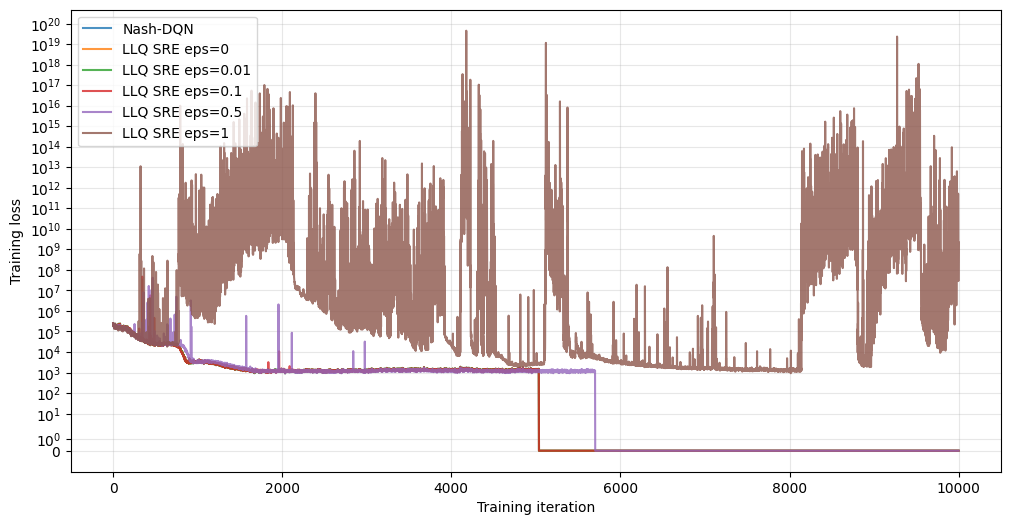

In [7]:
plt.figure(figsize=(12, 6))
if nash_loss is not None:
    plt.plot(nash_loss, label='Nash-DQN', alpha=0.8)
for eps, loss in llq_sre_losses.items():
    plt.plot(loss, label=f'LLQ SRE eps={eps:g}', alpha=0.8)
plt.yscale('symlog')
plt.xlabel('Training iteration')
plt.ylabel('Training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()